# Neural text classification

We will use [ag_news](https://paperswithcode.com/dataset/ag-news) dataset. This dataset is used for news classification into 4 topics: "World", "Sports", "Business", "Sci/Tech".

In [ ]:
!pip install datasets scikit-learn torch matplotlib nltk seaborn

Libraries import

In [37]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import datasets

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
import nltk

from collections import Counter
from typing import List
import string

import seaborn
seaborn.set(palette='summer')

In [38]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/mikhailvokhrameev/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [39]:
device = 'mps' if torch.mps.is_available() else 'cpu'
device

'mps'

## Data preparation

In [40]:
# Load the dataset
dataset = datasets.load_dataset('fancyzhx/ag_news')

Create vocabulary

In [54]:
words = Counter()

for example in tqdm(dataset['train']['text']):
    processed_text = example.lower().translate(
        str.maketrans('', '', string.punctuation))

    for word in word_tokenize(processed_text):
        words[word] += 1


vocab = set(['<unk>', '<bos>', '<eos>', '<pad>'])
counter_threshold = 25

for word, cnt in words.items():
    if cnt > counter_threshold:
        vocab.add(word)

print(f'Vocab size: {len(vocab)}')

word2ind = {word: i for i, word in enumerate(vocab)}
ind2word = {i: word for word, i in word2ind.items()}

100%|██████████| 120000/120000 [00:20<00:00, 5992.02it/s]

Vocab size: 11842


In [55]:
class WordDataset:
    def __init__(self, sentences):
        self.data = sentences
        self.unk_id = word2ind['<unk>']
        self.bos_id = word2ind['<bos>']
        self.eos_id = word2ind['<eos>']
        self.pad_id = word2ind['<pad>']

    def __getitem__(self, idx: int) -> List[int]:
        processed_text = self.data[idx]['text'].lower().translate(
            str.maketrans('', '', string.punctuation))
        tokenized_sentence = [self.bos_id]
        tokenized_sentence += [
            word2ind.get(word, self.unk_id) for word in word_tokenize(processed_text)
            ] 
        tokenized_sentence += [self.eos_id]

        train_sample = {
            "text": tokenized_sentence,
            "label": self.data[idx]['label']
        }

        return train_sample

    def __len__(self) -> int:
        return len(self.data)


In [56]:
def collate_fn_with_padding(
    input_batch: List[List[int]], pad_id=word2ind['<pad>'], max_len=256) -> torch.Tensor:
    seq_lens = [len(x['text']) for x in input_batch]
    max_seq_len = min(max(seq_lens), max_len)

    new_batch = []
    for sequence in input_batch:
        sequence['text'] = sequence['text'][:max_seq_len]
        for _ in range(max_seq_len - len(sequence['text'])):
            sequence['text'].append(pad_id)

        new_batch.append(sequence['text'])
    
    sequences = torch.LongTensor(new_batch).to(device)
    labels = torch.LongTensor([x['label'] for x in input_batch]).to(device)

    new_batch = {
        'input_ids': sequences,
        'label': labels
    }

    return new_batch

In [57]:
train_dataset = WordDataset(dataset['train'])

np.random.seed(42)
idx = np.random.choice(np.arange(len(dataset['test'])), 5000)
eval_dataset = WordDataset(dataset['test'].select(idx))

batch_size = 32
train_dataloader = DataLoader(
    train_dataset, shuffle=True, collate_fn=collate_fn_with_padding, batch_size=batch_size)

eval_dataloader = DataLoader(
    eval_dataset, shuffle=False, collate_fn=collate_fn_with_padding, batch_size=batch_size)

In [64]:
def evaluate(model, eval_dataloader) -> float:
    """
    Calculate accuracy on validation dataloader.
    """

    predictions = []
    target = []
    with torch.no_grad():
        for batch in eval_dataloader:
            logits = model(batch['input_ids'])
            predictions.append(logits.argmax(dim=1))
            target.append(batch['label'])
    
    predictions = torch.cat(predictions)
    target = torch.cat(target)
    accuracy = (predictions == target).float().mean().item()

    return accuracy

In [65]:
def train( model, num_epoch: int=5):
    eval_steps = len(train_dataloader) // 2

    losses = []
    acc = []

    # Ignore <pad> token during CrossEntropyLoss computation
    criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
    optimizer = torch.optim.Adam(model.parameters())

    for epoch in range(num_epoch):
        epoch_losses = []
        model.train()
        
        for i, batch in enumerate(tqdm(train_dataloader, desc=f'Training epoch {epoch}:')):
            optimizer.zero_grad()
            logits = model(batch['input_ids'])
            loss = criterion(logits, batch['label'])
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())
            
            # Validation in the middle and in the end of an epoch
            if i % eval_steps == 0:
                model.eval()
                acc.append(evaluate(model, eval_dataloader))
                model.train()

        losses.append(sum(epoch_losses) / len(epoch_losses))
        
    return acc, losses

In [66]:
def plots(acc, losses):
    plt.plot(
        np.arange(1, len(acc) + 1),
        acc,
        marker='o',
        label='Accuracy'
    )

    plt.title('Accuracy')
    plt.xlabel('Evaluation step')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    print(f"Best accuracy: {max(acc):.4f}")

    plt.plot(
        np.arange(1, len(losses) + 1),
        losses,
        marker='o',
        label='Loss'
    )

    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

### Basic RNN model class

In [67]:
class RNN_base(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int, num_classes: int = 4, aggregation_type: str = 'max'):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.RNN(hidden_dim, hidden_dim, batch_first=True)
        
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, num_classes)
        
        self.act = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)
        
        self.aggregation_type = aggregation_type
        
    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embeddings = self.embedding(input_batch)
        rnn_output, _ = self.rnn(embeddings)
        
        if self.aggregation_type == 'max':
            output = rnn_output.max(dim=1)[0]  # [batch_size, hidden_dim]
        elif self.aggregation_type == 'mean':
            output = rnn_output.mean(dim=1)    # [batch_size, hidden_dim]
        else:
            raise ValueError("Invalid aggregation_type")
        
        output = self.dropout(self.linear(self.act(output)))
        
        prediction = self.projection(self.act(output))
        
        return prediction
        

Training epoch 4:: 100%|██████████| 3750/3750 [03:52<00:00, 16.14it/s]


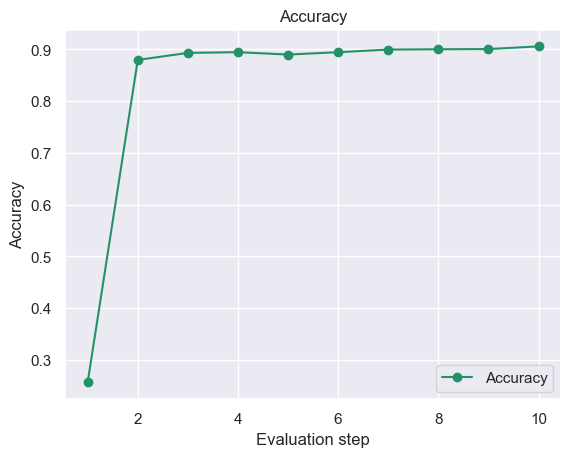

Best accuracy: 0.9056


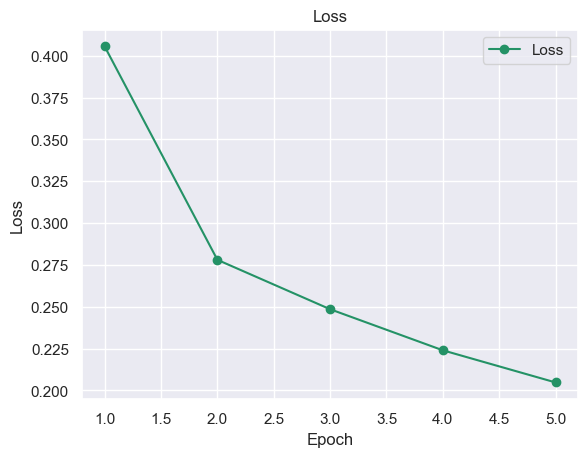

In [68]:
# Initialize model, loss func and optimizer
model = RNN_base(hidden_dim=256, vocab_size=len(vocab), aggregation_type= 'max').to(device)

acc, losses = train(model, 5)
plots(acc, losses)

Training epoch 4:: 100%|██████████| 3750/3750 [03:44<00:00, 16.74it/s] 


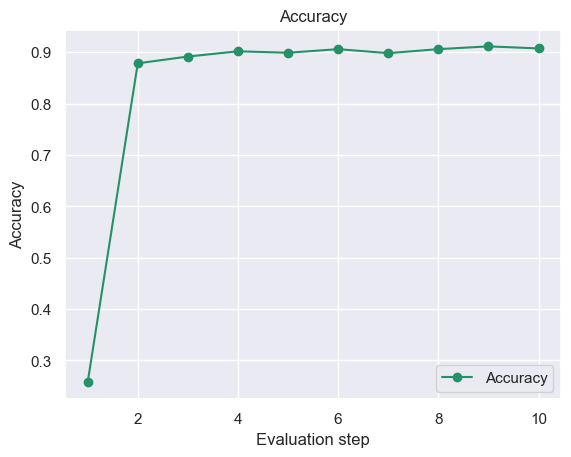

Best accuracy: 0.9114


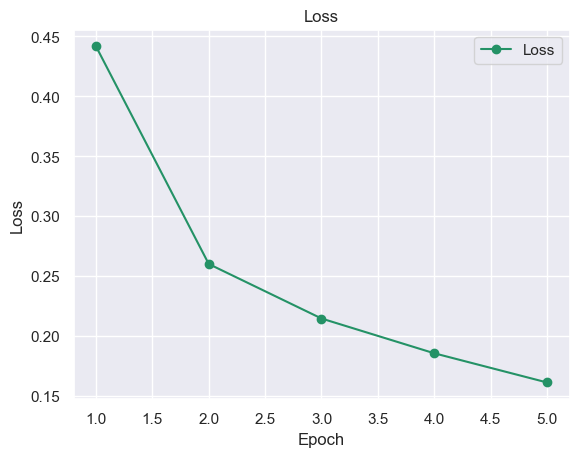

In [69]:
model = RNN_base(hidden_dim=256, vocab_size=len(vocab), aggregation_type= 'mean').to(device)

acc, losses = train(model, 5)
plots(acc, losses)

### Model with increased  number of RNN layers

In [72]:
class RNN_increased(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int, num_classes: int = 4, aggregation_type: str = 'mean'):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.RNN(hidden_dim, hidden_dim, batch_first=True, num_layers=3)
        
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, num_classes)
        
        self.act = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)
        
        self.aggregation_type = aggregation_type
        
    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embeddings = self.embedding(input_batch)
        rnn_output, _ = self.rnn(embeddings)
        
        if self.aggregation_type == 'max':
            output = rnn_output.max(dim=1)[0]  # [batch_size, hidden_dim]
        elif self.aggregation_type == 'mean':
            output = rnn_output.mean(dim=1)    # [batch_size, hidden_dim]
        else:
            raise ValueError("Invalid aggregation_type")
        
        output = self.dropout(self.linear(self.act(output)))
        
        prediction = self.projection(self.act(output))
        
        return prediction
        

Training epoch 4:: 100%|██████████| 3750/3750 [06:58<00:00,  8.96it/s]


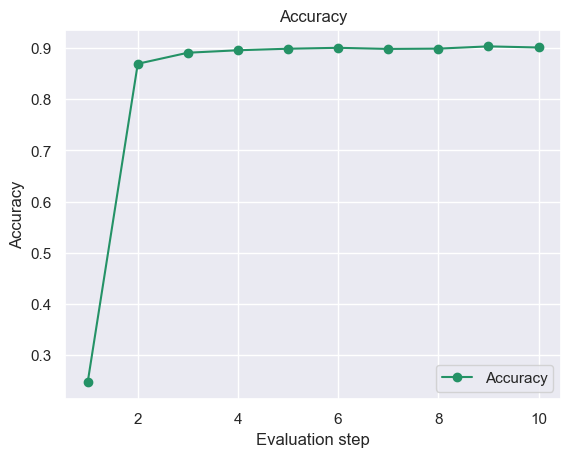

Best accuracy: 0.9032


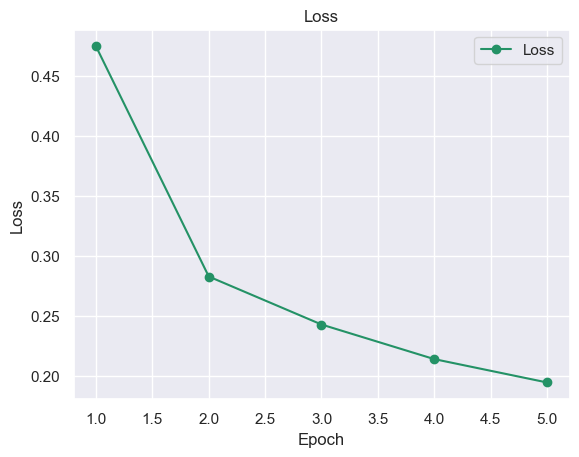

In [73]:
model = RNN_increased(hidden_dim=256, vocab_size=len(vocab), aggregation_type= 'mean').to(device)

acc, losses = train(model, 5)
plots(acc, losses)

### GRU

In [74]:
class RNN_GRU(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int, num_classes: int = 4, aggregation_type: str = 'max'):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, num_classes)
        
        self.act = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)
        
        self.aggregation_type = aggregation_type
        
    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embeddings = self.embedding(input_batch)
        rnn_output, _ = self.rnn(embeddings)
        
        if self.aggregation_type == 'max':
            output = rnn_output.max(dim=1)[0]  # [batch_size, hidden_dim]
        elif self.aggregation_type == 'mean':
            output = rnn_output.mean(dim=1)    # [batch_size, hidden_dim]
        else:
            raise ValueError("Invalid aggregation_type")
        
        output = self.dropout(self.linear(self.act(output)))
        
        prediction = self.projection(self.act(output))
        
        return prediction
        

Training epoch 4:: 100%|██████████| 3750/3750 [03:47<00:00, 16.50it/s]


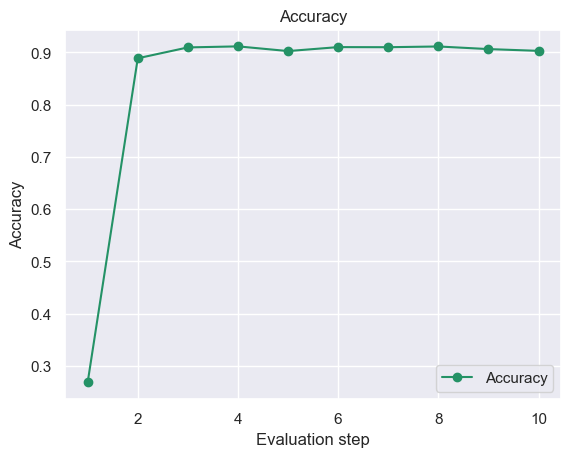

Best accuracy: 0.9116


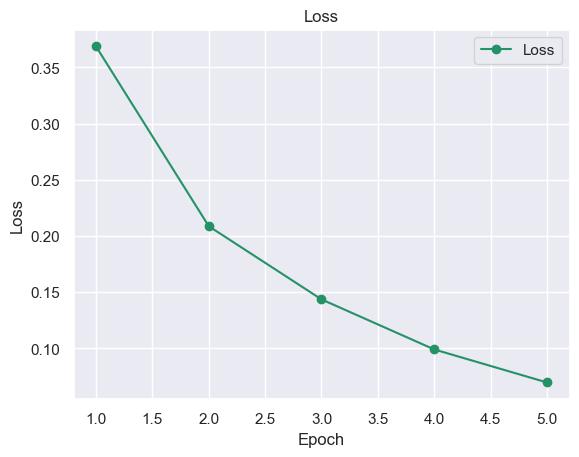

In [75]:
model = RNN_GRU(hidden_dim=256, vocab_size=len(vocab), aggregation_type= 'mean').to(device)

acc, losses = train(model, 5)
plots(acc, losses)

### LSTM

In [77]:
class RNN_LSTM(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int, num_classes: int = 4, aggregation_type: str = 'max'):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, num_classes)
        
        self.act = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)
        
        self.aggregation_type = aggregation_type
        
    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embeddings = self.embedding(input_batch)
        rnn_output, _ = self.rnn(embeddings)
        
        if self.aggregation_type == 'max':
            output = rnn_output.max(dim=1)[0]  # [batch_size, hidden_dim]
        elif self.aggregation_type == 'mean':
            output = rnn_output.mean(dim=1)    # [batch_size, hidden_dim]
        else:
            raise ValueError("Invalid aggregation_type")
        
        output = self.dropout(self.linear(self.act(output)))
        
        prediction = self.projection(self.act(output))
        
        return prediction
        

Training epoch 4:: 100%|██████████| 3750/3750 [01:40<00:00, 37.40it/s]


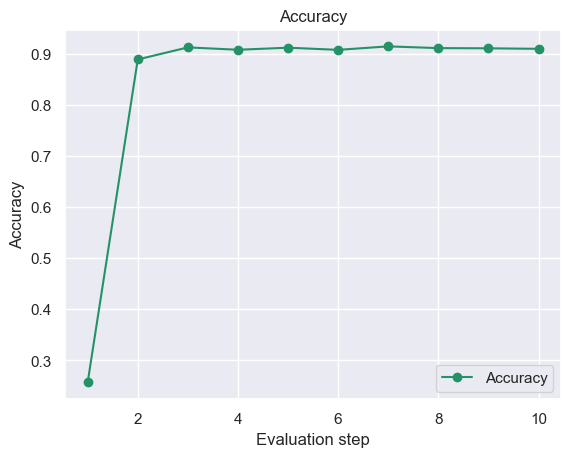

Best accuracy: 0.9140


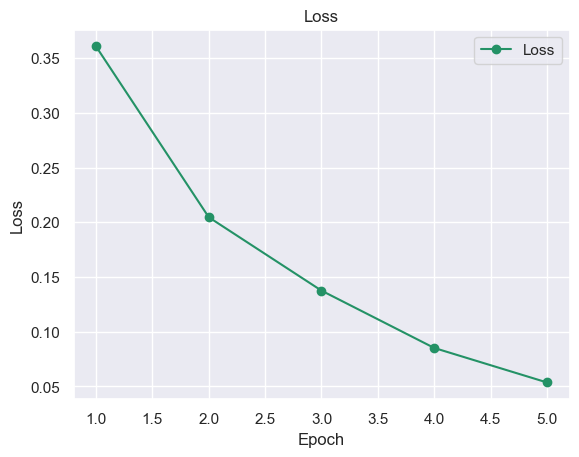

In [78]:
model = RNN_LSTM(hidden_dim=256, vocab_size=len(vocab), aggregation_type= 'mean').to(device)

acc, losses = train(model, 5)
plots(acc, losses)

### Model with aggregated output and last output concatenation

In [80]:
class RNN_concat(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int, num_classes: int = 4, aggregation_type: str = 'max'):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.RNN(hidden_dim, hidden_dim, batch_first=True)
        
        self.linear = nn.Linear(hidden_dim*2, hidden_dim)
        self.projection = nn.Linear(hidden_dim, num_classes)
        
        self.act = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)
        
        self.aggregation_type = aggregation_type
        
    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embeddings = self.embedding(input_batch)
        rnn_output, _ = self.rnn(embeddings)
        
        if self.aggregation_type == 'max':
            aggregated_output = rnn_output.max(dim=1)[0]  # [batch_size, hidden_dim]
        elif self.aggregation_type == 'mean':
            aggregated_output = rnn_output.mean(dim=1)    # [batch_size, hidden_dim]
        else:
            raise ValueError("Invalid aggregation_type")
        
        last_output = rnn_output[:, -1, :]
        
        output = torch.cat([aggregated_output, last_output], dim=1) # [batch_size, hidden_dim*2]
        
        output = self.dropout(self.linear(self.act(output)))
        
        prediction = self.projection(self.act(output))
        
        return prediction
        

Training epoch 4:: 100%|██████████| 3750/3750 [02:05<00:00, 29.87it/s]


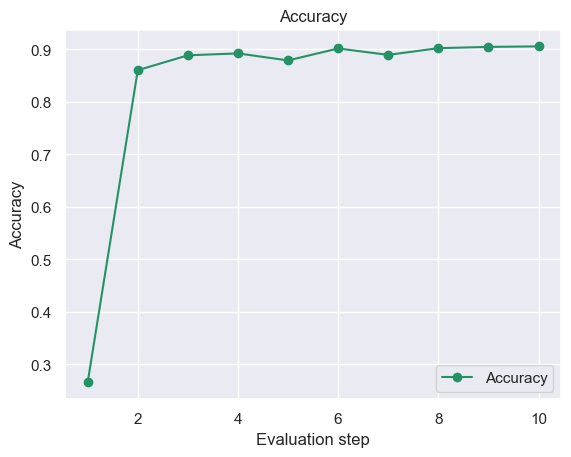

Best accuracy: 0.9058


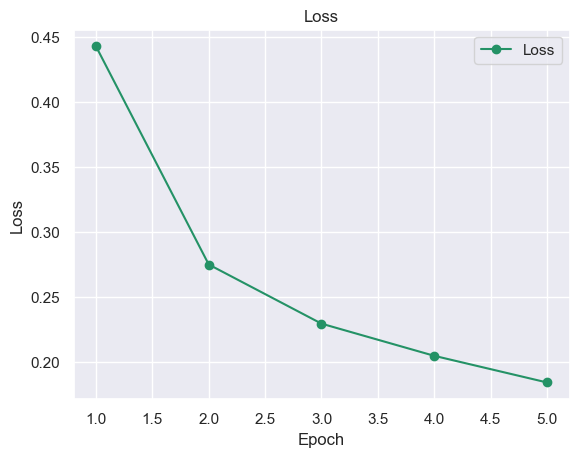

In [81]:
model = RNN_concat(hidden_dim=256, vocab_size=len(vocab), aggregation_type= 'mean').to(device)

acc, losses = train(model, 5)
plots(acc, losses)

### Conclusion

* Укажите, какие из экспериментов принесли улучшение, а какие - нет. 
* Проанализируйте графики сходимости моделей в проведенных экспериментах. Являются ли колебания качества обученных моделей существенными в зависимости от эпохи обучения, или же сходимость стабильная? 
* Укажите, какая модель получилась оптимальной.